In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [ ]:
#load the datasets
fake = pd.read_csv("../data/Fake.csv")
true = pd.read_csv("../data/True.csv")
#..is used to go back one directory level, and then we go into the data folder and read the Fake.csv file

In [3]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [8]:
# Labels 1 = Fake, 0 = Real
fake["label"] = 1
true["label"] = 0

print(f"Fake news rows: {len(fake)}")
print(f"Real news rows: {len(true)}")

Fake news rows: 23481
Real news rows: 21417


In [9]:
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [10]:
# Combine both datasets into one
df = pd.concat([fake, true], ignore_index=True)

In [12]:
df

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1
...,...,...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",0
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",0
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",0
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",0


In [13]:
# Shuffle so fake and real rows are mixed
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [14]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


In [15]:
# Check if any column has missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


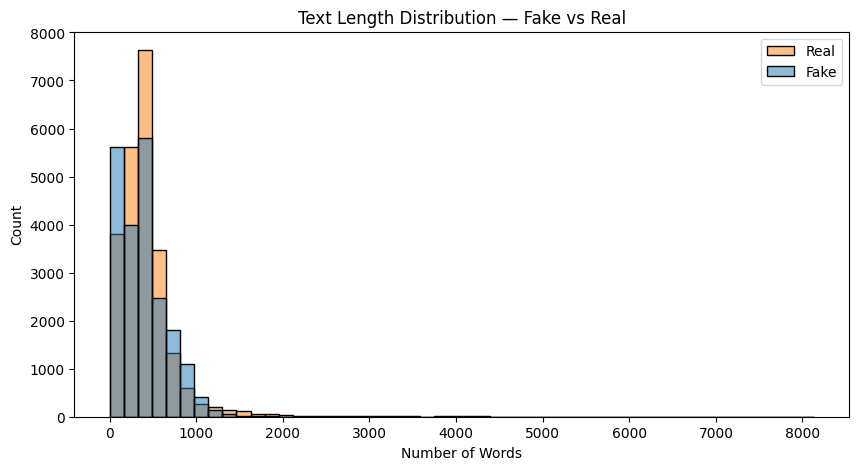

Average words in Fake news: 423
Average words in Real news: 386


In [16]:
# Add a new column for text length (number of words)
df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))

# Plot text length for fake vs real
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="text_length", hue="label", bins=50)
plt.title("Text Length Distribution — Fake vs Real")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.legend(["Real", "Fake"])
plt.show()

print(f"Average words in Fake news: {df[df['label']==1]['text_length'].mean():.0f}")
print(f"Average words in Real news: {df[df['label']==0]['text_length'].mean():.0f}")

In [ ]:
#From the above output and plot some insights we can draw are:
#1. Some real news articles are very long.
#2. But on average, fake news articles are shorter than real news articles.

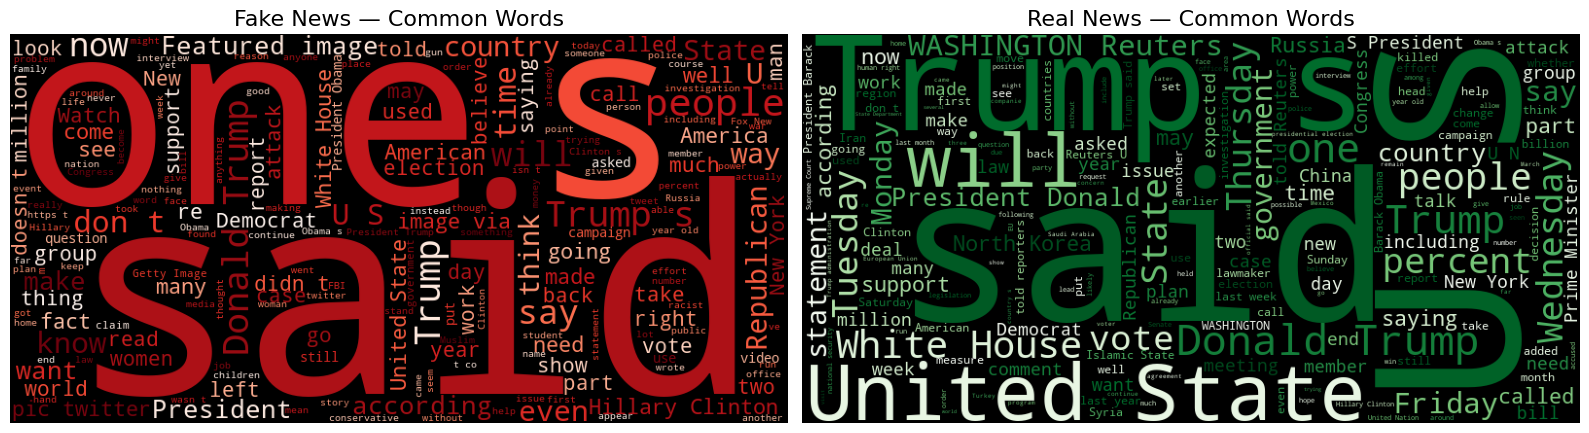

In [17]:
from wordcloud import WordCloud

# Converting all text from fake and real news into one big string for wordcloud generation
fake_text = " ".join(df[df["label"] == 1]["text"].astype(str).tolist())
real_text = " ".join(df[df["label"] == 0]["text"].astype(str).tolist())

# Plot dono wordclouds side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fake news wordcloud
fake_wc = WordCloud(width=800, height=400, 
                    background_color="black",
                    colormap="Reds").generate(fake_text)
axes[0].imshow(fake_wc)
axes[0].set_title("Fake News — Common Words", fontsize=16)
axes[0].axis("off")

# Real news wordcloud
real_wc = WordCloud(width=800, height=400, 
                    background_color="black",
                    colormap="Greens").generate(real_text)
axes[1].imshow(real_wc)
axes[1].set_title("Real News — Common Words", fontsize=16)
axes[1].axis("off")

plt.tight_layout()
plt.show()